<a href="https://colab.research.google.com/github/Rageel-28/244107020136-Machine-Learning/blob/main/JS06/JS06_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS06 - Klasifikasi 2 (Support Vector Machine)
## Tugas Lab

1. Buat model SVM dengan data **`voice.csv`**:
   - Split data rasio **70:30** dan **80:20** untuk setiap model.
   - Kernel **linier**, **polynomial**, dan **RBF**.
   - Tabulasikan akurasi setiap split dan kernel.
2. Gunakan data praktikum 5 (siang/malam) untuk klasifikasi SVM kernel **RBF** dengan fitur **histogram**, rasio **80:20**. Lakukan hyperparameter tuning RBF dan catat akurasinya.

**File yang dibutuhkan** (letakkan di folder yang sama dengan notebook, atau upload di Colab):
- `voice.csv` (unduh dari halaman Tugas Lab)
- zip dataset siang/malam dari Lab 5 (folder `images/training` dan `images/test`)

# Soal 1 - SVM pada data voice.csv

## 1.1 Import Library dan Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('voice.csv')
print(df.shape)
df.head()

(3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


## 1.2 Inspeksi Data

In [ ]:
df.info()
print()
print('Distribusi label:')
print(df['label'].value_counts())
print()
print('Missing value per kolom:')
print(df.isnull().sum().sum(), 'total')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

## 1.3 Pemisahan Fitur dan Label
Kolom `label` (male/female) adalah target; 20 kolom lainnya adalah fitur akustik.

In [ ]:
X = df.drop(columns=['label'])
y = df['label']
print(X.shape, y.shape)

(3168, 20) (3168,)


## 1.4 Pelatihan dan Evaluasi
Untuk setiap rasio split (70:30 dan 80:20) dan setiap kernel (linear, polynomial, RBF), dilatih model SVM dan dihitung akurasi pada data uji.

Catatan metodologi:
- Split menggunakan `stratify=y` agar proporsi male/female terjaga dan `random_state=42` agar hasil dapat direproduksi.
- Fitur distandardisasi dengan `StandardScaler` di dalam *pipeline*, sehingga scaler hanya di-fit pada data latih (tidak ada kebocoran data). Standardisasi penting karena SVM sensitif terhadap skala fitur.
- Parameter lain menggunakan default scikit-learn (`C=1`, polynomial `degree=3`, `gamma='scale'`).

In [ ]:
splits = {'70:30': 0.30, '80:20': 0.20}
kernels = ['linear', 'poly', 'rbf']

results = []
for split_name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y)

    for kernel in kernels:
        clf = make_pipeline(StandardScaler(), SVC(kernel=kernel))
        clf.fit(X_train, y_train)

        acc_train = accuracy_score(y_train, clf.predict(X_train))
        acc_test = accuracy_score(y_test, clf.predict(X_test))

        results.append({'Split': split_name, 'Kernel': kernel,
                        'Data Latih': len(X_train), 'Data Uji': len(X_test),
                        'Akurasi Latih': acc_train, 'Akurasi Uji': acc_test})

res_df = pd.DataFrame(results)
res_df

,Split,Kernel,Data Latih,Data Uji,Akurasi Latih,Akurasi Uji
0,70:30,linear,2217,951,0.972034,0.978970
1,70:30,poly,2217,951,0.966622,0.960042
2,70:30,rbf,2217,951,0.983762,0.983176
3,80:20,linear,2534,634,0.976717,0.974763
4,80:20,poly,2534,634,0.968035,0.955836
5,80:20,rbf,2534,634,0.983820,0.982650


## 1.5 Tabel Perbandingan Akurasi (Data Uji)

Akurasi data uji:


Split,70:30,80:20
Kernel,,
linear,97.9 %,97.48 %
poly,96.0 %,95.58 %
rbf,98.32 %,98.26 %


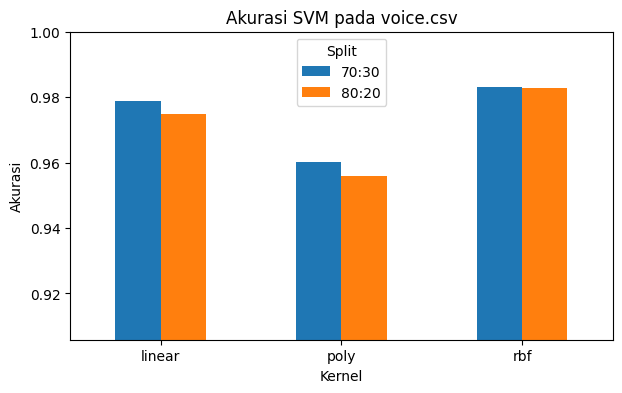

In [ ]:
tabel = res_df.pivot(index='Kernel', columns='Split', values='Akurasi Uji')
tabel = tabel.loc[['linear', 'poly', 'rbf']]
tabel_persen = (tabel * 100).round(2).astype(str) + ' %'
print('Akurasi data uji:')
display(tabel_persen)

tabel.plot(kind='bar', figsize=(7, 4))
plt.ylabel('Akurasi')
plt.title('Akurasi SVM pada voice.csv')
plt.ylim(max(0, tabel.values.min() - 0.05), 1.0)
plt.xticks(rotation=0)
plt.legend(title='Split')
plt.show()

## 1.6 Detail Performa Model Terbaik

Model terbaik: rbf | split 70:30 | akurasi uji = 0.9832
              precision    recall  f1-score   support

      female       0.99      0.98      0.98       476
        male       0.98      0.99      0.98       475

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



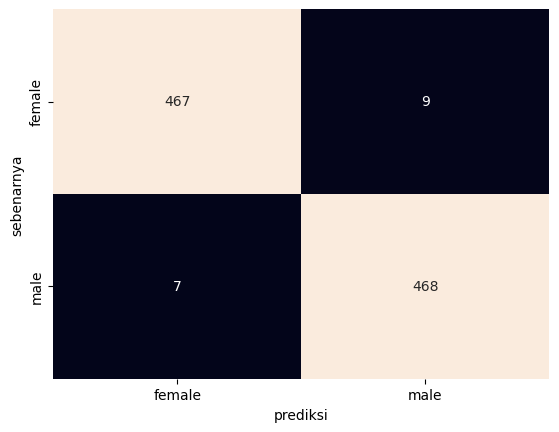

In [ ]:
best = res_df.sort_values('Akurasi Uji', ascending=False).iloc[0]
print('Model terbaik:', best['Kernel'], '| split', best['Split'], f"| akurasi uji = {best['Akurasi Uji']:.4f}")

test_size = splits[best['Split']]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y)
clf = make_pipeline(StandardScaler(), SVC(kernel=best['Kernel'])).fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cbar=False,
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('prediksi'); plt.ylabel('sebenarnya')
plt.show()

## 1.7 Analisis
*(Isi/ubah analisis ini setelah melihat hasil Anda sendiri.)*

- Bandingkan akurasi ketiga kernel pada kedua rasio split. Kernel yang memberi akurasi uji tertinggi menunjukkan bentuk batas keputusan yang paling sesuai dengan data suara.
- Bandingkan akurasi latih dan uji untuk melihat indikasi overfitting (terutama pada kernel polynomial).
- Perbedaan antara split 70:30 dan 80:20 umumnya kecil; split 80:20 memberi data latih lebih banyak, tetapi data uji lebih sedikit sehingga estimasi akurasi lebih bervariasi.

# Soal 2 - Klasifikasi Siang dan Malam (SVM RBF, fitur histogram)

## 2.1 Import Library dan Load Data
Data diambil dari praktikum 5. Karena soal meminta rasio 80:20, gambar dari folder `training` dan `test` digabung terlebih dahulu, lalu dibagi ulang 80:20.

In [ ]:
from pathlib import Path
import os, zipfile, glob
import matplotlib.image as mpimg
import cv2

DATASET_ZIP = "images.zip"

if not os.path.isdir("images"):
    zips = [DATASET_ZIP] if os.path.exists(DATASET_ZIP) else glob.glob("*.zip")
    if zips:
        with zipfile.ZipFile(zips[0]) as z:
            z.extractall(".")
        print("Diekstrak dari", zips[0])
    else:
        print("PERHATIAN: folder 'images' dan file zip tidak ditemukan. Unggah dataset terlebih dahulu.")

def load_dataset(img_dir):
    img_list = []
    for d in Path(img_dir).glob('*'):
        for file in d.glob('*.jpg'):
            img = mpimg.imread(file)
            if img is not None:
                img_list.append((img, d.name))
    return img_list

all_img = load_dataset("images/training/") + load_dataset("images/test/")
print('Total gambar:', len(all_img))
print(pd.Series([l for _, l in all_img]).value_counts())

Diekstrak dari images.zip
Total gambar: 400
day      200
night    200
Name: count, dtype: int64


## 2.2 Pra Pengolahan Data
Seperti Lab 5: ukuran gambar distandarkan ke 1100x600 dan label di-encode (day = 1, night = 0).

In [ ]:
def preprocess(img_list):
    out = []
    for img, label in img_list:
        std = cv2.resize(img, (1100, 600))
        out.append((std, 1 if label == 'day' else 0))
    return out

all_std = preprocess(all_img)
print(all_std[0][0].shape)

(600, 1100, 3)


## 2.3 Ekstraksi Fitur Histogram
Fitur berupa histogram warna: histogram 32 bin untuk tiap channel R, G, B (total 96 fitur), dinormalisasi agar jumlahnya 1 sehingga tidak bergantung pada ukuran gambar.

In [ ]:
def color_histogram(image, bins=32):
    feats = []
    for ch in range(3):
        h = cv2.calcHist([image], [ch], None, [bins], [0, 256]).flatten()
        h = h / h.sum()
        feats.extend(h)
    return np.array(feats)

X_hist = np.array([color_histogram(img) for img, _ in all_std])
y_hist = np.array([lbl for _, lbl in all_std])
print('Shape fitur:', X_hist.shape)

Shape fitur: (400, 96)


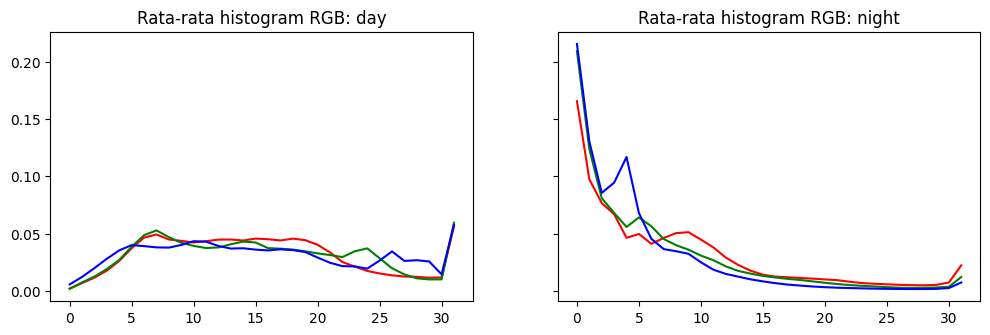

In [ ]:
# visualisasi rata-rata histogram per kelas (kanal V dari HSV tidak dipakai; ini histogram RGB)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for lbl, name in [(1, 'day'), (0, 'night')]:
    mean_h = X_hist[y_hist == lbl].mean(axis=0)
    for ch, col in enumerate(['r', 'g', 'b']):
        ax[0 if lbl == 1 else 1].plot(mean_h[ch*32:(ch+1)*32], color=col)
    ax[0 if lbl == 1 else 1].set_title(f'Rata-rata histogram RGB: {name}')
plt.show()

## 2.4 Split Data 80:20

In [ ]:
Xtr, Xte, ytr, yte = train_test_split(
    X_hist, y_hist, test_size=0.20, random_state=42, stratify=y_hist)
print('Latih:', Xtr.shape, '| Uji:', Xte.shape)

Latih: (320, 96) | Uji: (80, 96)


## 2.5 Baseline: SVM RBF dengan Parameter Default

In [ ]:
base = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
base.fit(Xtr, ytr)
acc_base = accuracy_score(yte, base.predict(Xte))
print(f'Akurasi baseline (C=1, gamma=scale): {acc_base:.4f}')

Akurasi baseline (C=1, gamma=scale): 1.0000


## 2.6 Hyperparameter Tuning (`C` dan `gamma`)
Dicari kombinasi terbaik dengan `GridSearchCV` (5-fold cross-validation **hanya pada data latih**). Data uji baru dipakai sekali di akhir untuk melaporkan akurasi.

In [ ]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
param_grid = {'svc__C': [0.1, 1, 10, 100, 1000],
              'svc__gamma': ['scale', 0.0001, 0.001, 0.01, 0.1]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(Xtr, ytr)

print('Parameter terbaik :', grid.best_params_)
print(f'Akurasi CV terbaik: {grid.best_score_:.4f}')

Parameter terbaik : {'svc__C': 100, 'svc__gamma': 0.001}
Akurasi CV terbaik: 0.9969


param_svc__gamma,0.0001,0.001,0.01,0.1,scale
param_svc__C,,,,,
0.1,0.9500,0.9219,0.9625,0.7312,0.9594
1.0,0.9312,0.9875,0.9812,0.9875,0.9812
10.0,0.9875,0.9812,0.9875,0.9875,0.9875
100.0,0.9781,0.9969,0.9875,0.9875,0.9875
1000.0,0.9938,0.9969,0.9875,0.9875,0.9875


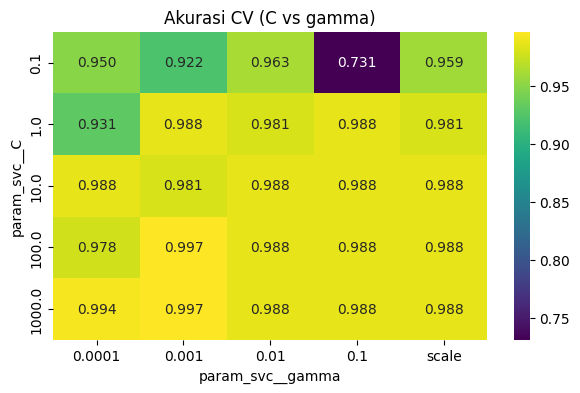

In [ ]:
# tabel hasil seluruh kombinasi (akurasi CV rata-rata)
cv = pd.DataFrame(grid.cv_results_)
cv_tab = cv.pivot_table(index='param_svc__C', columns='param_svc__gamma',
                        values='mean_test_score', aggfunc='mean')
display(cv_tab.round(4))

plt.figure(figsize=(7, 4))
sns.heatmap(cv_tab.astype(float), annot=True, fmt='.3f', cmap='viridis')
plt.title('Akurasi CV (C vs gamma)')
plt.show()

## 2.7 Evaluasi Akhir pada Data Uji

Akurasi data uji (baseline) : 1.0000
Akurasi data uji (tuning)   : 1.0000

              precision    recall  f1-score   support

       night       1.00      1.00      1.00        40
         day       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



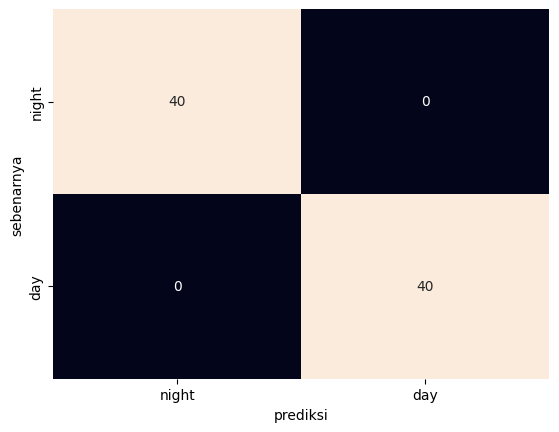

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(Xte)
acc_best = accuracy_score(yte, y_pred)

print(f'Akurasi data uji (baseline) : {acc_base:.4f}')
print(f'Akurasi data uji (tuning)   : {acc_best:.4f}')
print()
print(classification_report(yte, y_pred, target_names=['night', 'day']))

sns.heatmap(confusion_matrix(yte, y_pred), annot=True, fmt='d', cbar=False,
            xticklabels=['night', 'day'], yticklabels=['night', 'day'])
plt.xlabel('prediksi'); plt.ylabel('sebenarnya')
plt.show()

## 2.8 Catatan Performansi

In [ ]:
catatan = pd.DataFrame([
    {'Model': 'SVM RBF (default)', 'C': 1, 'gamma': 'scale', 'Akurasi Uji': acc_base},
    {'Model': 'SVM RBF (tuning)', 'C': grid.best_params_['svc__C'],
     'gamma': grid.best_params_['svc__gamma'], 'Akurasi Uji': acc_best},
])
catatan

,Model,C,gamma,Akurasi Uji
0,SVM RBF (default),1,scale,1.0
1,SVM RBF (tuning),100,0.001,1.0


## 2.9 Analisis
*(Isi/ubah setelah melihat hasil Anda.)*

- Bandingkan akurasi baseline dan hasil tuning. Jika selisihnya kecil, fitur histogram sudah cukup memisahkan siang dan malam dan model tidak terlalu sensitif terhadap `C` dan `gamma`.
- Nilai `gamma` yang terlalu besar membuat batas keputusan terlalu rumit (risiko overfitting), sedangkan `gamma` terlalu kecil membuat batas terlalu halus (underfitting).
- Bandingkan dengan Lab 5 yang hanya memakai satu fitur (rata-rata kecerahan): fitur histogram memuat informasi distribusi warna, bukan hanya kecerahan rata-rata.